<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/19_NaiveBayes_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Naive Bayes로 TSLA 방향성 예측 (분류)
이 노트북은 다음 거래일의 **상승/하락(이진 분류)**을 예측합니다.
시계열에서는 **시간 순서 보존(train→test)**과 **정보누수 방지**가 핵심입니다.


## 알고리즘 직관: Gaussian Naive Bayes

### 1. 기본 원리 (Bayes' Theorem)
나이브 베이즈는 베이즈 정리를 기반으로 합니다. 특정 데이터(X)가 주어졌을 때 해당 클래스(y, 상승 또는 하락)에 속할 확률을 계산합니다.

$$P(y|X) = \frac{P(X|y)P(y)}{P(X)}$$

- $P(y|X)$: 사후 확률 (데이터가 주어졌을 때 상승/하락할 확률)
- $P(X|y)$: 우도 (상승/하락장일 때 해당 데이터 패턴이 나타날 확률)
- $P(y)$: 사전 확률 (과거 데이터에서 상승/하락이 나타난 전체 비율)

### 2. 'Naive(순진한)' 가정
모든 특징(Feature)들이 서로 독립적이라고 가정합니다. 실제 금융 데이터에서 지표들은 서로 연관되어 있지만, 이 가정을 통해 계산 속도가 비약적으로 빨라지며 적은 데이터로도 기준선(Baseline) 모델로서 훌륭한 성능을 냅니다.

### 3. Gaussian(가우시안)
연속적인 데이터(주가 수익률 등)를 다룰 때, 각 특징이 정규분포(종 모양)를 따른다고 가정하고 확률을 계산하는 방식입니다.

## 0) 환경 준비
```bash
pip install yfinance
```


In [4]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)


## 1) 데이터 수집 (2025-03-30 ~ 2026-03-30, 최근 1년)


In [12]:
# 1. 데이터 수집
df = yf.download("TSLA", start="2024-03-30", end="2025-03-30", auto_adjust=True, progress=False).reset_index()
print("데이터 수집 완료. 전체 행 수:", len(df))
df.head()

데이터 수집 완료. 전체 행 수: 250


Price,Date,Close,High,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
0,2024-04-01,175.220001,176.750000,170.210007,176.169998,81562100
1,2024-04-02,166.630005,167.690002,163.429993,164.750000,116650600
2,2024-04-03,168.380005,168.820007,163.279999,164.020004,82950100
3,2024-04-04,171.110001,177.190002,168.009995,170.070007,123162000
4,2024-04-05,164.899994,170.860001,160.509995,169.080002,143157600


## 2) 특징 생성(과거 정보만 사용)


### 🔍 피처(Feature) 상세 설명
모델이 시장의 상태를 구분하기 위해 사용하는 7가지 지표입니다.

1. ret_lag1 ~ ret_lag10 (Lagged Returns):
   - 설명: 각각 1, 2, 3, 5, 10일 전의 주가 수익률입니다.
   - 의도: 과거의 수익률 패턴이 시장 상태 결정에 어떤 영향을 주는지 확인합니다.

2. ma_gap (MA Cross Over Distance):
   - 계산: (5일 이동평균 / 20일 이동평균) - 1.0
   - 설명: 단기 평균 가격과 중기 평균 가격 사이의 거리입니다.
   - 의도: 현재 주가가 단기적으로 과열되었는지 또는 추세가 전환되는 시점(골든/데드크로스)인지를 판단합니다.

3. vol10 (Rolling Volatility):
   - 계산: 최근 10일간 수익률의 표준편차
   - 설명: 시장의 위험도와 변동폭을 측정합니다.
   - 의도: 공포 장세(고변동성)와 안정 장세(저변동성)를 구분하는 핵심 지표입니다.

In [19]:
# 특징(Feature) 생성: 과거 정보만 사용하여 미래 예측 준비
# 1일 수익률 계산
df['ret1'] = df['Close'].pct_change()

# 과거 n일 전의 수익률들을 특징으로 추가 (시차 변수)
for k in [1, 2, 3, 5, 10]:
    df[f'ret_lag{k}'] = df['ret1'].shift(k)

# 이동평균선 계산 (단기 5일, 중기 20일)
df['ma5']  = df['Close'].rolling(5).mean()
df['ma20'] = df['Close'].rolling(20).mean()

# 이격도: 단기평균이 중기평균보다 얼마나 위에 있는지 비율로 계산
df['ma_gap'] = (df['ma5'] / df['ma20']) - 1.0

# 변동성: 최근 10일간 수익률이 얼마나 출렁였는지 표준편차로 계산
df['vol10'] = df['ret1'].rolling(10).std()

# 계산에 필요한 과거 데이터가 부족한 초기 행 제거
df = df.dropna().reset_index(drop=True)
print('특징 생성 완료. 데이터 수:', len(df))

특징 생성 완료. 데이터 수: 0


## 3) 타깃/분할(시간 순서 보존)


In [7]:
# 타깃: 다음날 상승(1) / 하락(0)
df['ret_next'] = df['Close'].pct_change().shift(-1)
df['y_bin'] = (df['ret_next'] > 0).astype(int)
df = df.dropna().reset_index(drop=True)

features = ['ret_lag1','ret_lag2','ret_lag3','ret_lag5','ret_lag10','ma_gap','vol10']
X = df[features]
y = df['y_bin']

# 시간 순서 보존 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (182, 7) Test: (46, 7)


## 4) 모델 학습


In [14]:
from sklearn.naive_bayes import GaussianNB

# 가우시안 나이브 베이즈 모델 정의
# 스케일러를 포함한 파이프라인 구성
model = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('nb', GaussianNB())
])

# 학습 데이터로 모델 훈련
model.fit(X_train, y_train)
print("모델 학습 완료.")

모델 학습 완료.


## 5) 평가


정확도(Accuracy): 0.4783
ROC-AUC 점수: 0.5390

상세 분류 리포트:
              precision    recall  f1-score   support

           0     0.4483    0.6190    0.5200        21
           1     0.5294    0.3600    0.4286        25

    accuracy                         0.4783        46
   macro avg     0.4888    0.4895    0.4743        46
weighted avg     0.4924    0.4783    0.4703        46



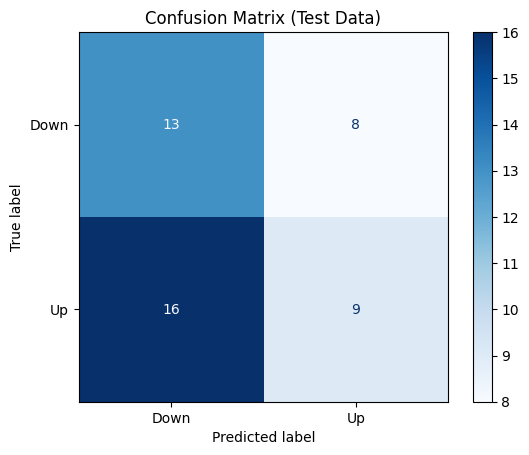

In [17]:
# 테스트 데이터에 대한 예측 수행
y_pred = model.predict(X_test)

# 모델의 예측 성능 평가
if hasattr(model, 'predict_proba'):
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
else:
    y_proba = None
    auc = None

acc = accuracy_score(y_test, y_pred)
print(f'정확도(Accuracy): {acc:.4f}')
if auc is not None:
    print(f'ROC-AUC 점수: {auc:.4f}')

print('\n상세 분류 리포트:')
print(classification_report(y_test, y_pred, digits=4))

# 혼동 행렬 시각화 (영문 레이블 사용)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (Test Data)')
plt.show()

## 6) 방향 요약 + 다음 거래일 예측


In [10]:
import numpy as np
import pandas as pd

prediction_counts = np.bincount(y_pred)
print(f"Predicted Down (하락): {prediction_counts[0] if len(prediction_counts) > 0 else 0} 건")
print(f"Predicted Up (상승): {prediction_counts[1] if len(prediction_counts) > 1 else 0} 건")

last_day_features = X.iloc[-1].values.reshape(1, -1)
next_day_prediction = model.predict(last_day_features)
prediction_label = "상승 (Up)" if int(next_day_prediction[0]) == 1 else "하락 (Down)"

last_date_in_df = df['Date'].iloc[-1]
predicted_date = last_date_in_df + pd.Timedelta(days=1)

print(f"다음 거래일 예측 (날짜: {predicted_date.strftime('%Y-%m-%d')}): {prediction_label}")


Predicted Down (하락): 29 건
Predicted Up (상승): 17 건
다음 거래일 예측 (날짜: 2026-03-25): 상승 (Up)


## ✅ 마지막 시각화(결과를 눈으로 확인)
마지막 셀은 반드시 그래프가 출력되도록 구성했습니다.


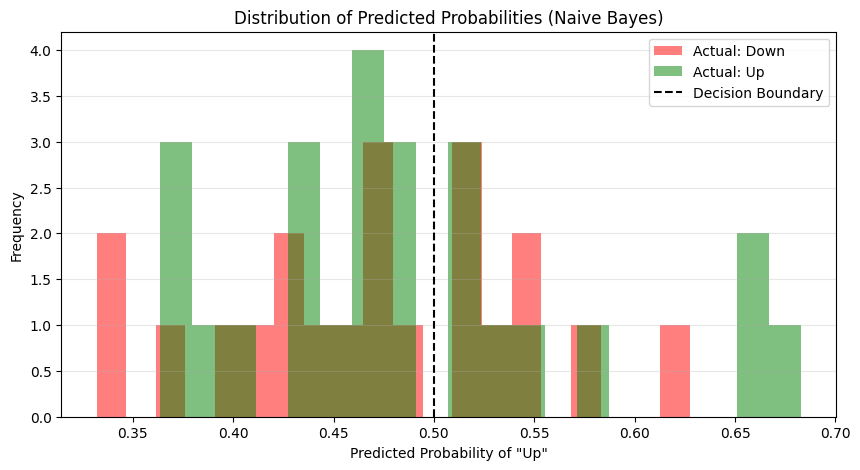

그래프 해석:
1. 0.5보다 오른쪽에 데이터가 많으면 모델이 상승으로 예측한 경우가 많은 것입니다.
2. Actual Up(초록)이 오른쪽 끝에, Actual Down(빨강)이 왼쪽 끝에 몰려있을수록 모델 성능이 우수합니다.
3. 현재 분포가 겹쳐 있다면, 과거 데이터만으로는 방향을 뚜렷하게 구분하기 어렵다는 의미입니다.


In [20]:
# 예측 확률 분포 시각화 및 해석
y_proba = model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(10, 5))
# 실제 하락(0)한 날들의 예측 확률
plt.hist(y_proba[y_test.values==0], bins=20, alpha=0.5, label='Actual: Down', color='red')
# 실제 상승(1)한 날들의 예측 확률
plt.hist(y_proba[y_test.values==1], bins=20, alpha=0.5, label='Actual: Up', color='green')

plt.axvline(0.5, color='black', linestyle='--', label='Decision Boundary')
plt.title('Distribution of Predicted Probabilities (Naive Bayes)')
plt.xlabel('Predicted Probability of "Up"')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print('그래프 해석:')
print('1. 0.5보다 오른쪽에 데이터가 많으면 모델이 상승으로 예측한 경우가 많은 것입니다.')
print('2. Actual Up(초록)이 오른쪽 끝에, Actual Down(빨강)이 왼쪽 끝에 몰려있을수록 모델 성능이 우수합니다.')
print('3. 현재 분포가 겹쳐 있다면, 과거 데이터만으로는 방향을 뚜렷하게 구분하기 어렵다는 의미입니다.')

## ✅ 요약(3줄)
1) 분류는 ‘가격’을 맞추는 것이 아니라 ‘방향(Up/Down)’을 예측합니다.
2) 시계열에서는 **시간 분할**과 **누수 방지**가 성능보다 먼저입니다.
3) 정확도만 보지 말고 AUC/혼동행렬/기준선과 함께 해석하세요.
